In [9]:
import os
import pandas as pd
from sqlalchemy import create_engine
import utils as api
from dotenv import load_dotenv
from sqlalchemy.exc import IntegrityError

In [10]:
#Load from .env file
load_dotenv()

# Load environment variables
tz = os.getenv('TZ')
API_KEY = os.getenv('API_KEY')
DB_URI = os.getenv('DB_URI')

# Create database engine
engine = create_engine(DB_URI)

In [11]:
#Fetch historical hourly prices for the past 24 hours
df_prices_24h = api.compute_moving_average(
    coin_id='bitcoin',
    vs_currency='usd',
    window=1,            # window=1 returns raw hourly prices
    api_key=API_KEY
)[['price']]

df_prices_24h.head()

,price
timestamp,
2025-04-29 03:04:53.530000+00:00,94634.347753
2025-04-29 04:04:55.231000+00:00,94711.855826
2025-04-29 05:04:53.801000+00:00,94402.847589
2025-04-29 06:05:22.025000+00:00,94309.341506
2025-04-29 07:04:52.243000+00:00,94736.903997


In [12]:
#Bulk insert all fetched 24h prices into PostgreSQL
for ts, row in df_prices_24h.iterrows():
    try:
        pd.DataFrame({'price': [row['price']]}, index=[ts]).to_sql(
            name='raw_prices',
            con=engine,
            if_exists='append',
            index_label='timestamp'
        )
    except IntegrityError:
        # Skip if this timestamp already exists
        continue
print("Inserted or skipped duplicates for the past 24h of data.")

Inserted or skipped duplicates for the past 24h of data.



**Note:** We now fetch all hourly data points for the last 24h in one call and insert them in bulk, avoiding row-by-row timestamp collisions.


In [13]:
#  Fetch past 24h hourly data and compute a 60-period MA in one step
df_hourly = api.compute_moving_average(
    coin_id='bitcoin',
    vs_currency='usd',
    window=60,
    api_key=API_KEY  # optional for this endpoint
)

# Inspect the last few rows (timestamp, price, ma_60)
df_hourly[['price','ma_60']].tail()

,price,ma_60
timestamp,,
2025-04-29 22:02:36.643000+00:00,94734.091310,94903.318576
2025-04-29 23:06:44.527000+00:00,94172.730810,94868.528683
2025-04-30 00:04:51.368000+00:00,94274.737617,94841.538180
2025-04-30 01:04:49.115000+00:00,94516.297572,94827.397284
2025-04-30 02:07:46+00:00,94522.394958,94814.688853


In [15]:
# Persist hourly averages to PostgreSQL
df_hourly[['ma_60']].to_sql(
    name='hourly_avg',
    con=engine,
    if_exists='replace',
    index_label='timestamp'
)

24

> **Note:** The wrapper uses timezone-aware UTC timestamps to avoid dtype mismatches.

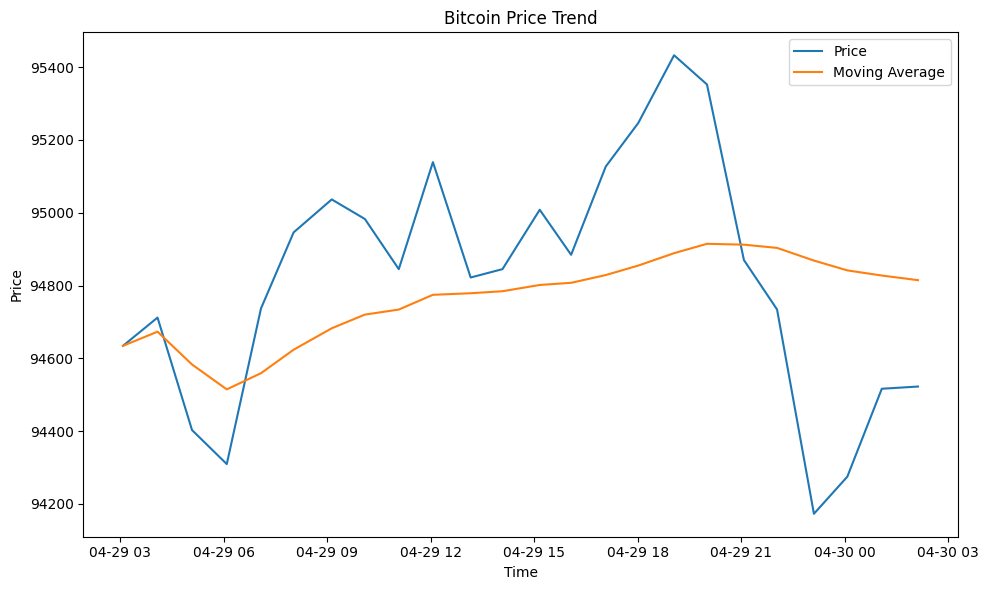

In [16]:
#Load last 24h of raw and averaged data from DB
cutoff = pd.Timestamp.now(tz=tz) - pd.Timedelta('24h')
query_plot = (
    "SELECT r.timestamp, r.price, h.ma_60"
    " FROM raw_prices r JOIN hourly_avg h USING (timestamp)"
    f" WHERE r.timestamp >= '{cutoff.isoformat()}'"
    " ORDER BY r.timestamp"
)
df_plot = pd.read_sql(query_plot, engine, index_col='timestamp')

#Plot with UTC-aware index
api.plot_price_trend(
    df_plot,
    price_col='price',
    ma_col='ma_60'
)